In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e2, 1e2, 1e2], dtype=float)




In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))


In [3]:
weight=None
filter_type = 'gaussian'
arepo_length = snap.length.uq
filter_length = 10*arepo_length

In [4]:
orientation = pa.Orientation(normal_vector=[1,-2,1], 
                            perp_vector1=[0,0.2,-0.3])

In [53]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
# sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
#                         search_radius=20.*filter_length.value)

sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=None)

In [54]:
sf.multiplier

4

In [55]:
filt_vec = sf.filter_variable(snap['0_Velocities'], filter_length, 
                                  weight=snap['0_Density'],  filter_type=filter_type, 
                                  iterative=False, selection=None)

In [56]:
filt_vec.shape

(911548, 3)

In [57]:
sf.tile.npixs

array([128, 128, 128])

In [58]:
sf.tile.tile_index

array([[63, 63, 63],
       [63, 63, 63],
       [63, 63, 63],
       ...,
       [64, 64, 64],
       [64, 64, 64],
       [64, 64, 64]])

In [71]:
np.sum(sf.indicesFirstPass)

120338

In [72]:
np.sum(sf.index)

911548

In [60]:
sf.tile.sort_index

array([    36,     42,     64, ..., 910385, 910556, 910719])

In [76]:
hsml = np.cbrt((snap["0_Volume"]) / (4.0 * np.pi / 3.0))
hsml = hsml.to(snap["0_Coordinates"].unit)

In [80]:
get_index = pa.util.get_index_of_cubic_region_plus_thin_layer
indicesfirstpass = get_index(snap["0_Coordinates"], center, widths, hsml, snap.box)

In [81]:
max_search_radius = np.max(sf.search_radius[indicesfirstpass])

In [82]:
max_search_radius


<PaicosQuantity 78.41498201 arepo_length small_a / small_h>

In [79]:
sf.search_radius

<PaicosQuantity [  41.99247271,   39.0111468 ,   43.70265479, ...,
                 1867.46019632, 1865.16739654, 1833.59694973] arepo_length small_a / small_h>

In [83]:

index = get_index(snap["0_Coordinates"], center, widths, hsml+max_search_radius, snap.box)

In [84]:
np.sum(index)

911548

In [85]:
sf.gpu_variables['pos']

array([[499839.92962337, 499880.37192879, 499703.50822278],
       [499841.48179934, 499879.46168002, 499702.54774245],
       [499840.14765975, 499878.98812964, 499702.12196611],
       ...,
       [499721.69729099, 499752.52283176, 499572.89428129],
       [499715.51114093, 499750.77623939, 499573.37691237],
       [499711.49859742, 499751.18726343, 499572.01576049]])

In [86]:
sf.tile._pos

array([[8395.7202639 , 8395.97506932, 8398.51761331],
       [8397.27243987, 8395.06482055, 8397.55713298],
       [8395.93830028, 8394.59127017, 8397.13135664],
       ...,
       [8277.48793152, 8268.12597229, 8267.90367182],
       [8271.30178146, 8266.37937992, 8268.3863029 ],
       [8267.28923795, 8266.79040396, 8267.02515102]])

In [65]:
sf.tile.tile_index[811548]

array([64, 64, 64])

In [66]:
sf.tile.tilebox_widths

array([16793.20628106, 16793.20628106, 16793.20628106])

In [67]:
sf.widths

<PaicosQuantity [100., 100., 100.] arepo_length small_a / small_h>

In [69]:
2*sf.extra_layer_thickness

16693.206281061914

In [39]:
filt_vec

<PaicosQuantity [[0., 0., 0.],
                 [0., 0., 0.],
                 [0., 0., 0.],
                 ...,
                 [0., 0., 0.],
                 [0., 0., 0.],
                 [0., 0., 0.]] arepo_velocity small_a(1/2)>

In [88]:
# filt_den = sf.filter_variable(snap['0_Density'], filter_length, weight=None,  
#                               filter_type=filter_type, iterative=False, optimized=True, 
#                               selection=None)

In [89]:
smooth_den, turb_den = tc.extract_turbulent_var(snap, sf, '0_Density', 
                                                   filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)

min/max/avg occupancy cartesian tiling 0 / 124457 / 0.43


In [103]:
filt_den = sf.filter_variable(snap['0_Density'], filter_length, 
                                  weight=None,  filter_type=filter_type, 
                                  iterative=False, selection=None)

In [105]:
filt_den.shape

(911548,)

In [116]:
sf.isParticleInDomain.astype('bool')

array([ True,  True,  True, ..., False, False, False])

In [123]:
filt_den_select = filt_den[cp.asnumpy(sf.isParticleInDomain.astype('bool'))]

In [128]:
np.argwhere(filt_den_select.value != 0.0)

array([[    16],
       [    36],
       [    42],
       ...,
       [119892],
       [120099],
       [120245]])

In [130]:
len(np.argwhere(filt_den_select.value != 0.0))

24126

In [131]:

cumulative_occupancy = cp.cumsum(sf.isParticleInDomain)
numParticlesInDomain = int(cumulative_occupancy[-1])

In [132]:
numParticlesInDomain

120338

In [121]:
cp.asnumpy(sf.isParticleInDomain.astype('bool'))

array([ True,  True,  True, ..., False, False, False])

In [106]:
sf.gpu_variables['filter_lengths']

array([10., 10., 10., ..., 10., 10., 10.])

In [108]:
np.sum(sf.isParticleInDomain)

array(120338.)

In [90]:
turb_den.max()

<PaicosQuantity nan small_h2 arepo_density / small_a3>

In [110]:
sf.hitsNeighboursUnSorted.shape

(911548,)

In [109]:
sf.hitsNeighboursUnSorted

array([    0,     0,     0, ...,     0, 32788,     0])

In [91]:
smooth_den.shape

(120358394,)

In [92]:
snap['0_Coordinates'].shape

(120358394, 3)

In [93]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
# slicer = pa.Slicer(snap, center, widths_slicer, orientation, npix=2048)
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [94]:
den_select = snap['0_Density'].copy

In [95]:
den_select[~sf.indicesFirstPass] *= 0

In [96]:
dens_tot = slicer.slice_variable(den_select)
dens_bulk = slicer.slice_variable(smooth_den)
dens_turb = slicer.slice_variable(turb_den)

In [99]:
dens_tot

<PaicosQuantity [[2.93941417e-26, 2.93941417e-26, 2.93941417e-26, ...,
                  2.09594832e-26, 2.09594832e-26, 2.09594832e-26],
                 [2.93941417e-26, 2.93941417e-26, 2.93941417e-26, ...,
                  2.09594832e-26, 2.09594832e-26, 2.09594832e-26],
                 [2.93941417e-26, 2.93941417e-26, 2.93941417e-26, ...,
                  2.09594832e-26, 2.09594832e-26, 2.09594832e-26],
                 ...,
                 [2.45790609e-26, 2.45790609e-26, 2.45790609e-26, ...,
                  2.24666026e-26, 2.24666026e-26, 2.24666026e-26],
                 [2.45790609e-26, 2.45790609e-26, 2.45790609e-26, ...,
                  2.24666026e-26, 2.24666026e-26, 2.24666026e-26],
                 [2.45790609e-26, 2.45790609e-26, 2.45790609e-26, ...,
                  2.24666026e-26, 2.24666026e-26, 2.24666026e-26]] g / cm3>

Text(0.5, 0.95, 'Density field (orientation)')

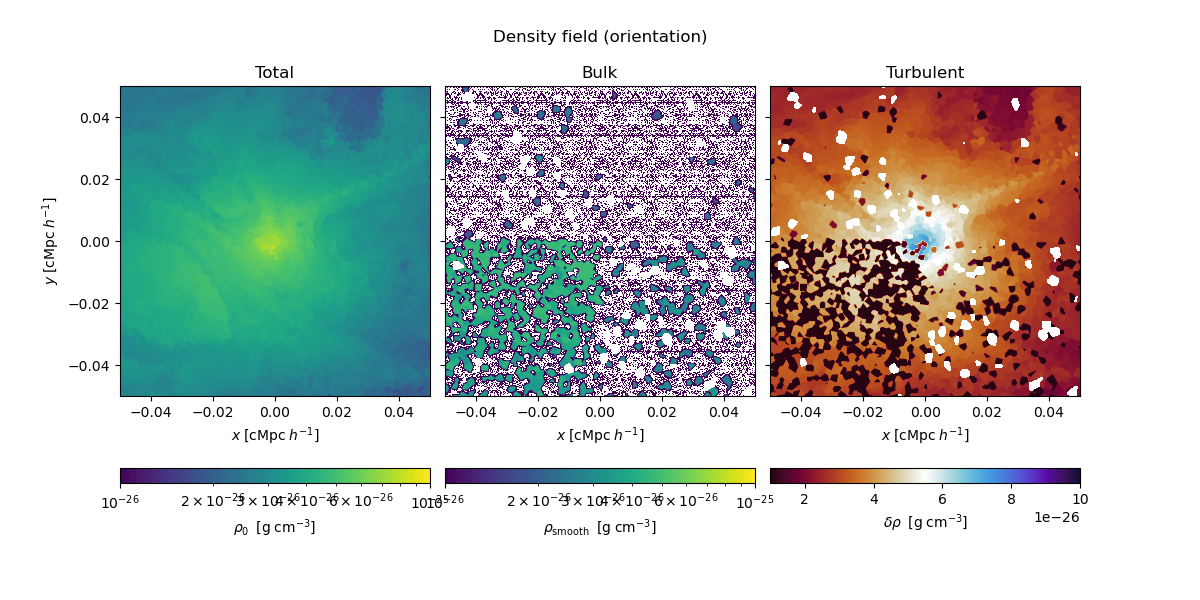

In [102]:

dens_tot = dens_tot.to_physical.cgs
dens_bulk = dens_bulk.to_physical.cgs
dens_turb = dens_turb.to_physical.cgs

vmin = 1e-26
vmax = 1e-25
norm = LogNorm(vmin=vmin,vmax=vmax)


# vmin = -0.8*dens_tot.value.max()
# vmax = 0.8*dens_tot.value.max()
norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = cmr.fusion

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    dens_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    dens_turb.value, origin='lower', norm=norm1,cmap=cmap,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_0'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_{\mathrm{smooth}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_tot.label('\\delta \\rho '))



fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (orientation)',y=0.95)
# plt.savefig('../plots/density_field.pdf')

In [ ]:
deriv_dens = sf.derivative_variable('0_Density', filter_length, weight=weight, 
                                       filter_type="gaussian", selection=None)

In [ ]:
deriv_dens.shape

In [ ]:
deriv_vec = sf.derivative_variable(snap['0_Velocities'], filter_length, weight=weight, 
                                       filter_type="gaussian", selection=None)

In [ ]:
deriv_vec.shape

In [ ]:
grad_vel = tc.extract_derivative_var(snap, sf, snap['0_Velocities'], filter_length, 
                                     filter_type="gaussian", 
                                     selection=None)

In [ ]:
grad_vel.shape

In [ ]:

e_K_smooth, eps_bulk, eps_cross, eps_turb = tc.decompose_kinetic_energy(snap, sf, 
                            snap['0_Density'], snap['0_Velocities'], 
                            filter_length,  weight, filter_type, iterative=False, 
                            recycle=False, snap_out=None, selection=None)

In [ ]:
eps_turb

In [ ]:
shear_matrix = tc.compute_shear_matrix(snap, sf, snap['0_Velocities'],  filter_length, 
                               filter_type,  weight='0_Density',
                               recycle=False, snap_out=None, selection=None)

In [ ]:
shear_matrix